In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

In [10]:
cohort_ret     = pd.read_csv('../data/processed/cohort_retention.csv')
cohort_pct     = pd.read_csv('../data/processed/cohort_retention_pct.csv')
cohort_rev     = pd.read_csv('../data/processed/cohort_revenue.csv')
cohort_aov     = pd.read_csv('../data/processed/cohort_aov.csv')
kpi_summary    = pd.read_csv('../data/processed/kpi_summary.csv')

print("All files loaded.")
print(kpi_summary.to_string(index=False))

All files loaded.
 TotalCustomers  TotalRevenue    AOV  RepeatPurchaseRate  AvgCLV
           4338     8911425.9 480.87              0.6558 2054.27


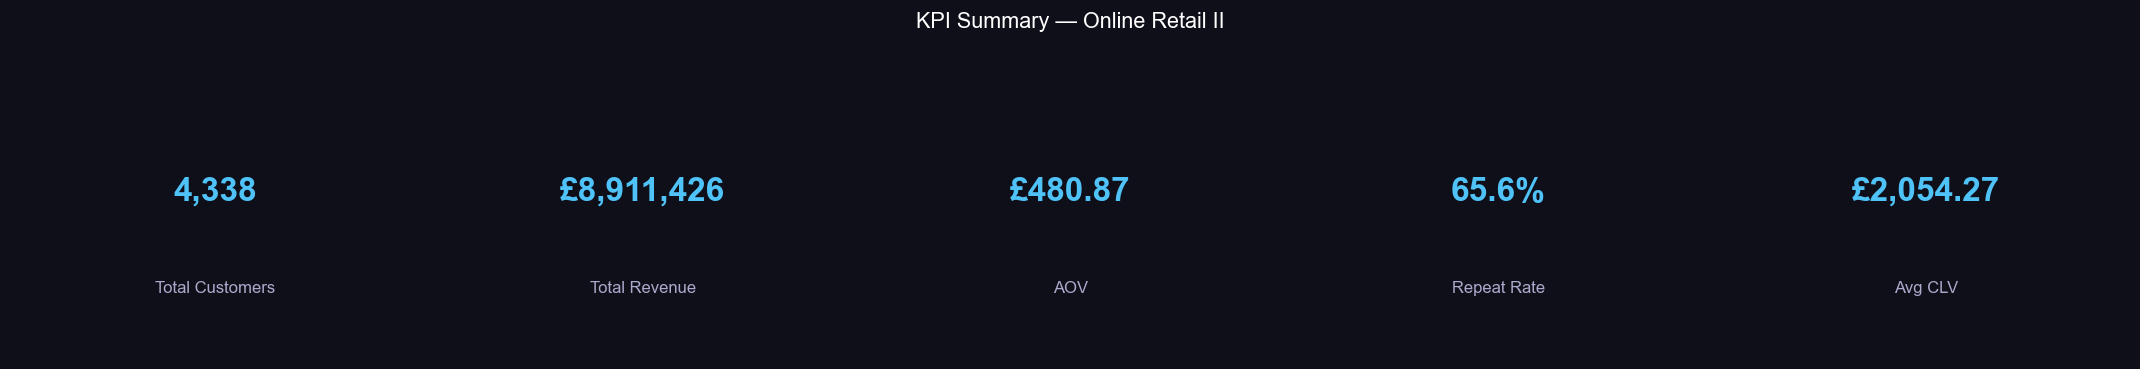

In [11]:
kpi = kpi_summary.iloc[0]

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
fig.patch.set_facecolor('#0f0f1a')

labels = ['Total Customers', 'Total Revenue', 'AOV', 'Repeat Rate', 'Avg CLV']
values = [
    f"{int(kpi['TotalCustomers']):,}",
    f"£{kpi['TotalRevenue']:,.0f}",
    f"£{kpi['AOV']:,.2f}",
    f"{kpi['RepeatPurchaseRate']*100:.1f}%",
    f"£{kpi['AvgCLV']:,.2f}"
]

for ax, label, value in zip(axes, labels, values):
    ax.set_facecolor('#1a1a2e')
    ax.text(0.5, 0.6, value, ha='center', va='center', fontsize=20,
            fontweight='bold', color='#4fc3f7', transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=10,
            color='#aaaacc', transform=ax.transAxes)
    ax.axis('off')

plt.suptitle('KPI Summary — Online Retail II', color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../report/kpi_cards.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

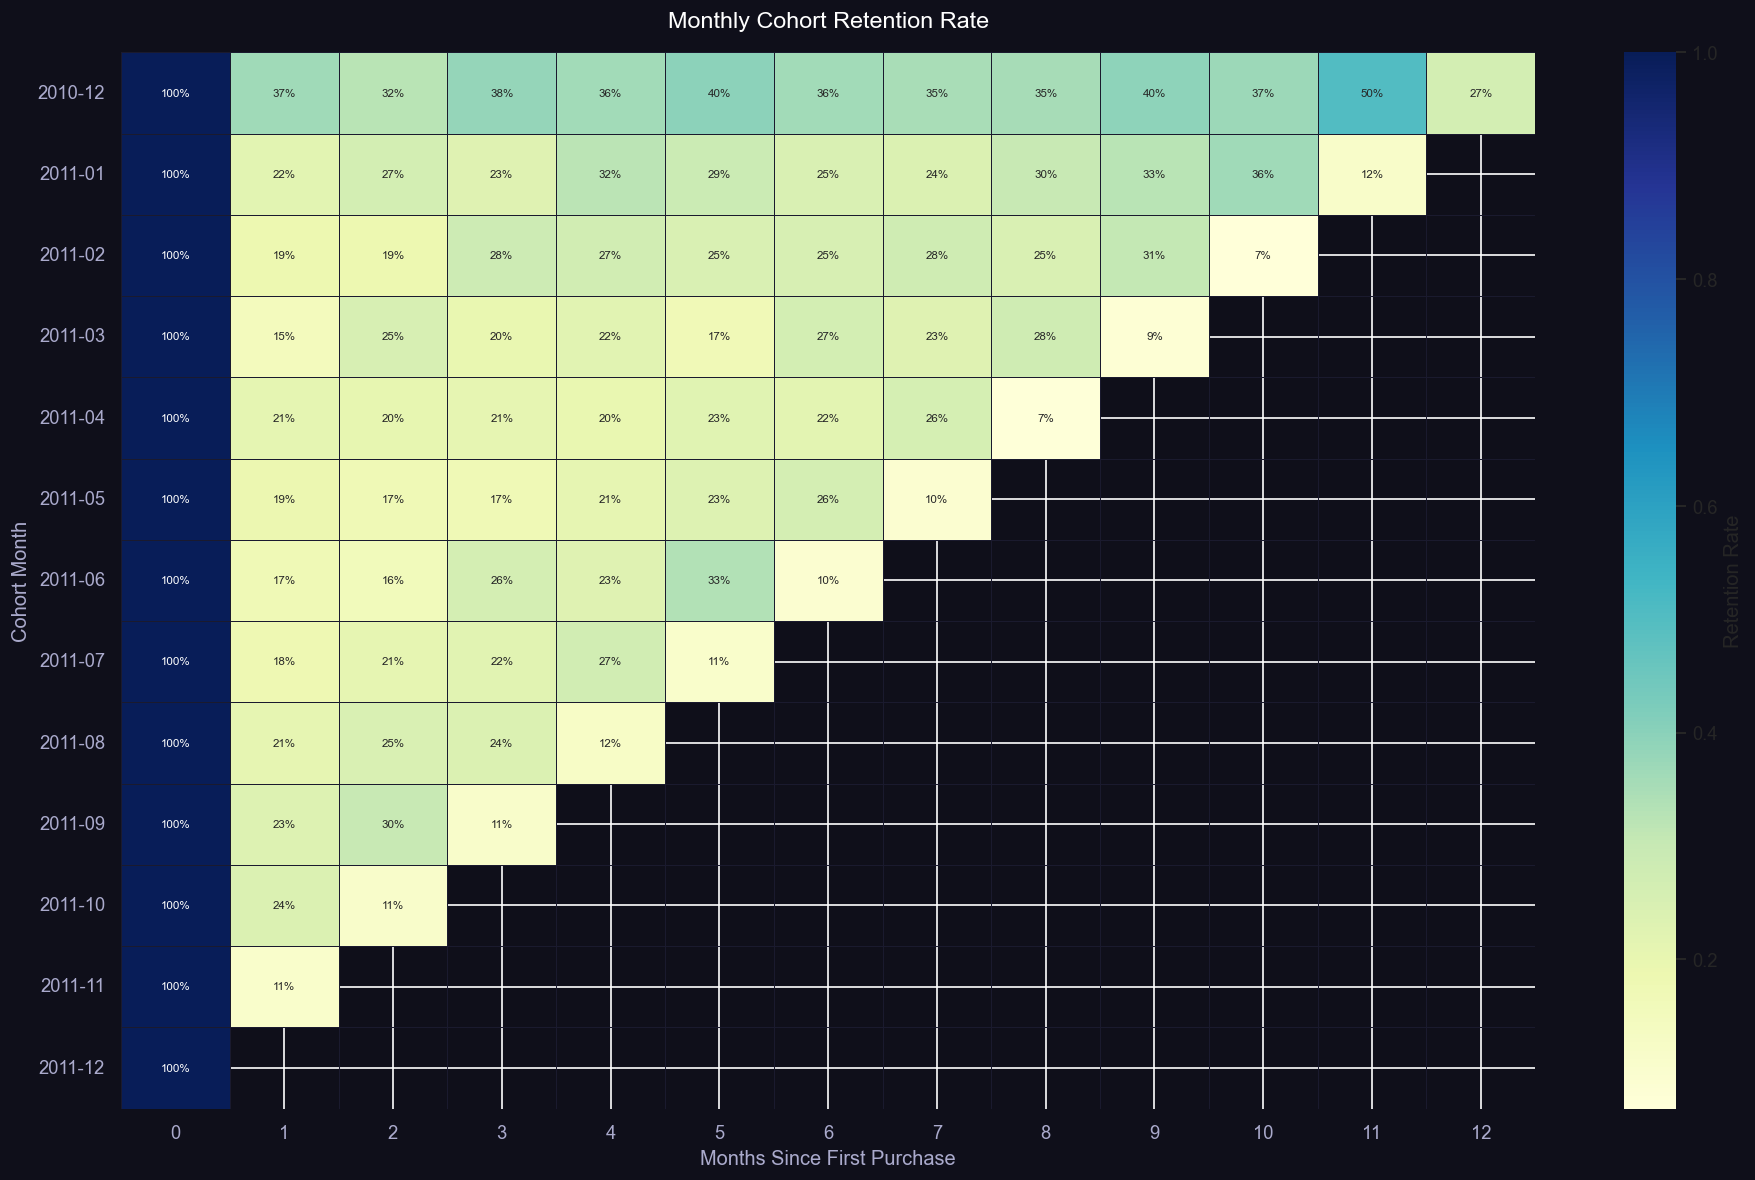

In [12]:
# Pivot for heatmap
pivot = cohort_pct.pivot(index='CohortMonth', columns='CohortIndex', values='RetentionRate')

fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

sns.heatmap(
    pivot,
    ax=ax,
    annot=True,
    fmt='.0%',
    cmap='YlGnBu',
    linewidths=0.3,
    linecolor='#1a1a2e',
    annot_kws={'size': 7},
    cbar_kws={'label': 'Retention Rate'}
)

ax.set_title('Monthly Cohort Retention Rate', color='white', fontsize=14, pad=15)
ax.set_xlabel('Months Since First Purchase', color='#aaaacc')
ax.set_ylabel('Cohort Month', color='#aaaacc')
ax.tick_params(colors='#aaaacc')
plt.setp(ax.get_xticklabels(), rotation=0)
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../report/retention_heatmap.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

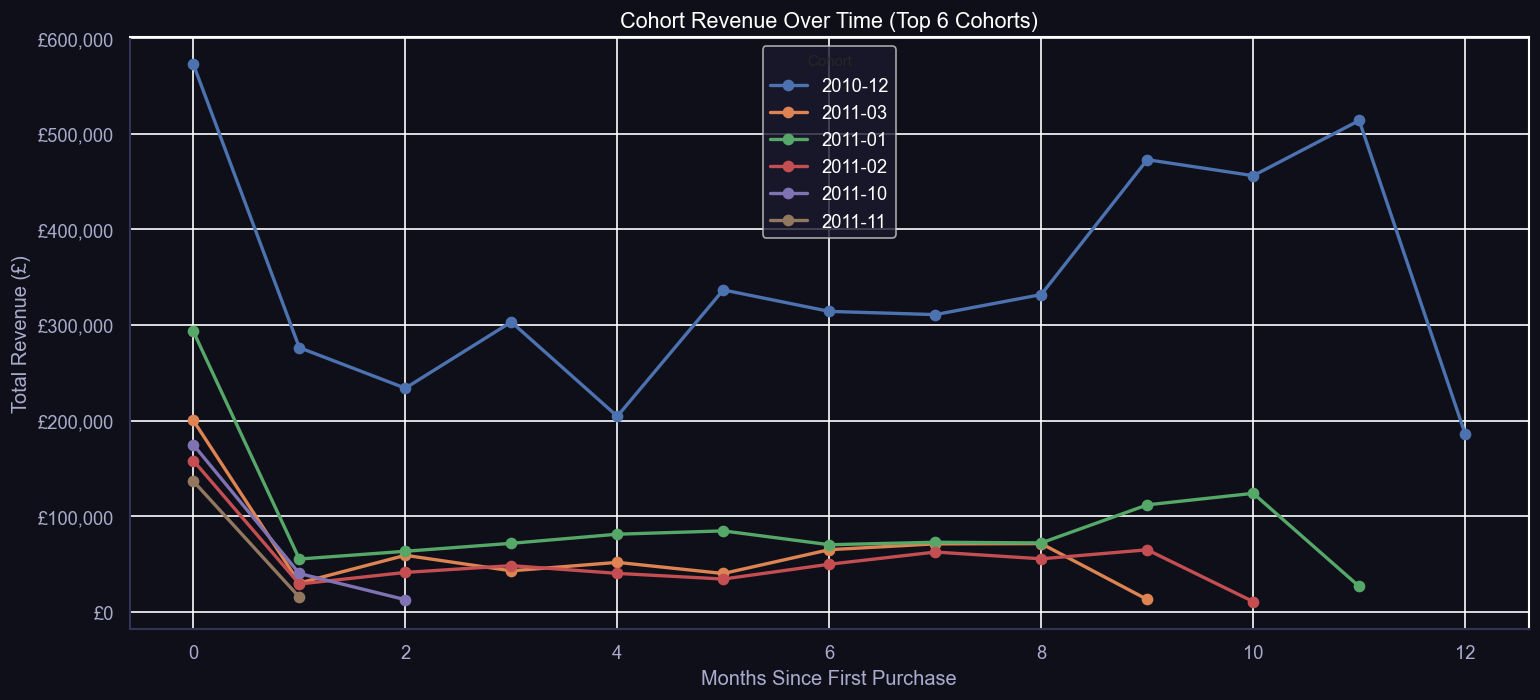

In [13]:
# Top 6 cohorts by initial size
top_cohorts = (
    cohort_ret[cohort_ret['CohortIndex'] == 0]
    .nlargest(6, 'Customers')['CohortMonth']
    .tolist()
)

rev_filtered = cohort_rev[cohort_rev['CohortMonth'].isin(top_cohorts)]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

for cohort in top_cohorts:
    data = rev_filtered[rev_filtered['CohortMonth'] == cohort]
    ax.plot(data['CohortIndex'], data['TotalRevenue'], marker='o', label=str(cohort), linewidth=2)

ax.set_title('Cohort Revenue Over Time (Top 6 Cohorts)', color='white', fontsize=13)
ax.set_xlabel('Months Since First Purchase', color='#aaaacc')
ax.set_ylabel('Total Revenue (£)', color='#aaaacc')
ax.tick_params(colors='#aaaacc')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(title='Cohort', facecolor='#1a1a2e', labelcolor='white', title_fontsize=9)
ax.spines['bottom'].set_color('#333355')
ax.spines['left'].set_color('#333355')

plt.tight_layout()
plt.savefig('../report/cohort_revenue.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

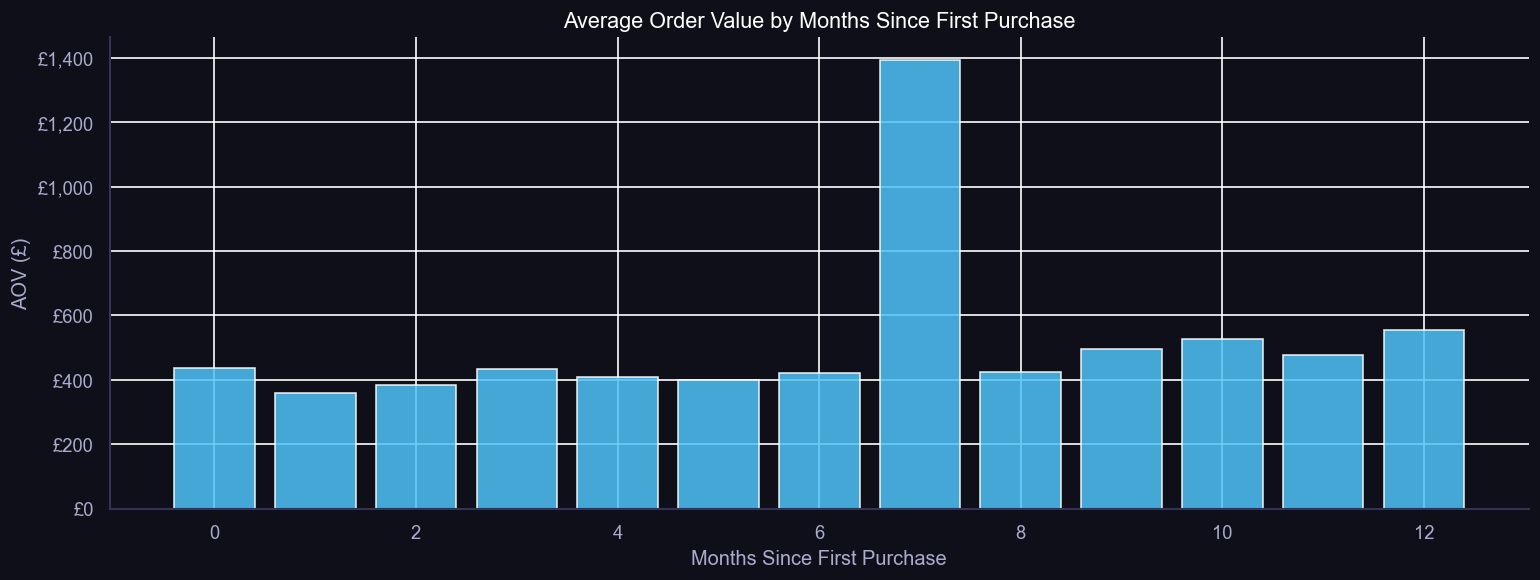

In [14]:
aov_avg = cohort_aov.groupby('CohortIndex')['AOV'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

ax.bar(aov_avg['CohortIndex'], aov_avg['AOV'], color='#4fc3f7', alpha=0.85)
ax.set_title('Average Order Value by Months Since First Purchase', color='white', fontsize=13)
ax.set_xlabel('Months Since First Purchase', color='#aaaacc')
ax.set_ylabel('AOV (£)', color='#aaaacc')
ax.tick_params(colors='#aaaacc')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.spines['bottom'].set_color('#333355')
ax.spines['left'].set_color('#333355')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../report/aov_by_cohort_index.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

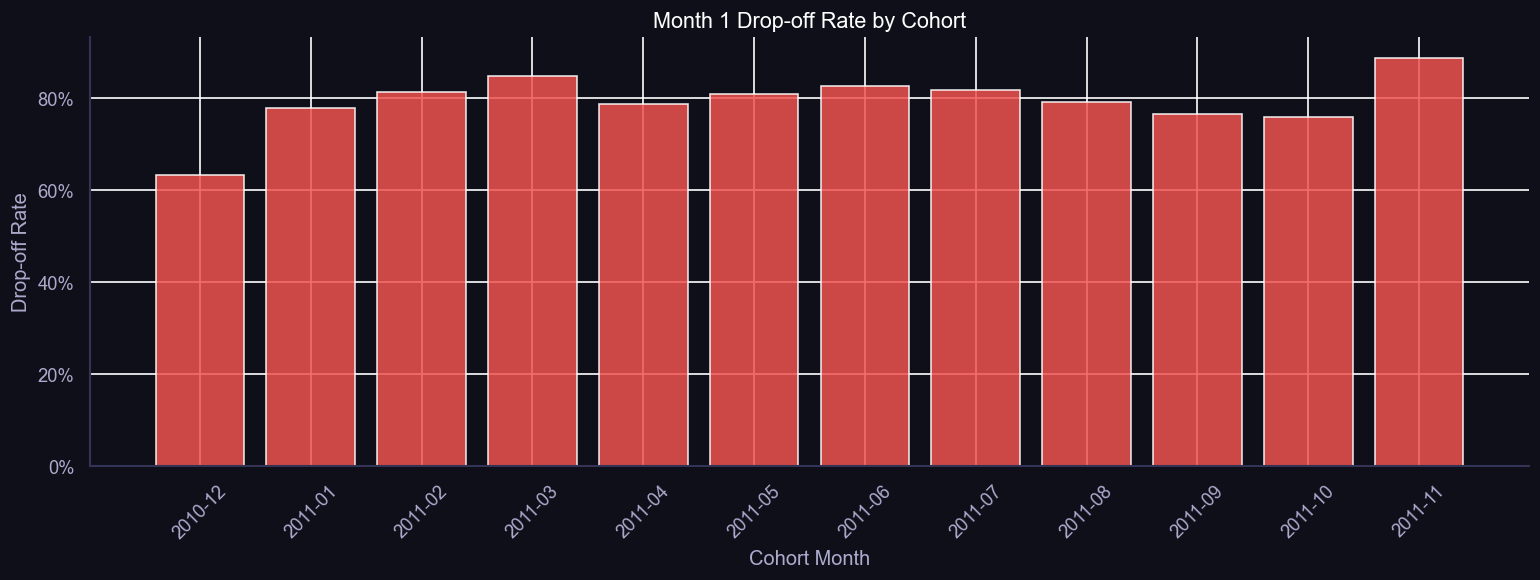

In [15]:
month0 = cohort_ret[cohort_ret['CohortIndex'] == 0].set_index('CohortMonth')['Customers']
month1 = cohort_ret[cohort_ret['CohortIndex'] == 1].set_index('CohortMonth')['Customers']

dropoff = pd.DataFrame({
    'Month0': month0,
    'Month1': month1
}).dropna()
dropoff['DropoffRate'] = ((dropoff['Month0'] - dropoff['Month1']) / dropoff['Month0']).round(4)

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')

ax.bar(dropoff.index.astype(str), dropoff['DropoffRate'], color='#ef5350', alpha=0.85)
ax.set_title('Month 1 Drop-off Rate by Cohort', color='white', fontsize=13)
ax.set_xlabel('Cohort Month', color='#aaaacc')
ax.set_ylabel('Drop-off Rate', color='#aaaacc')
ax.tick_params(colors='#aaaacc')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.xticks(rotation=45)
ax.spines['bottom'].set_color('#333355')
ax.spines['left'].set_color('#333355')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../report/dropoff_rate.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()